# 04 - Retrieval Evaluation

Evalúa recuperación texto-a-imagen e imagen-a-imagen usando labels GT solo como verdad de evaluación.

In [16]:
%pip install numpy pandas Pillow matplotlib seaborn torch torchvision open_clip_torch tqdm

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.0 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [17]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
from tqdm.auto import tqdm
import torch
import open_clip

PROJECT_ROOT = Path.cwd().resolve()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

OUTPUTS_DIR = PROJECT_ROOT / "outputs"
MODEL_NAME = "ViT-B-32"
PRETRAINED = "laion2b_s34b_b79k"
BATCH_SIZE = 64
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

CLASS_PROMPT_NAMES = {
    "0": "gun",
    "1": "knife",
    "2": "pliers",
    "3": "scissors",
    "4": "wrench",
}

CLASS_NAMES = list(CLASS_PROMPT_NAMES.values())

In [18]:
embeddings = np.load(OUTPUTS_DIR / "embeddings.npy").astype("float32")
text_embeddings = np.load(OUTPUTS_DIR / "text_embeddings.npy").astype("float32")
metadata = pd.read_csv(OUTPUTS_DIR / "embeddings_metadata.csv")
all_metadata = pd.read_csv(OUTPUTS_DIR / "crops_metadata.csv")

metadata["class_id"] = metadata["class_id"].astype(str)
metadata["class_name"] = metadata["class_id"].map(CLASS_PROMPT_NAMES)
all_metadata["class_id"] = all_metadata["class_id"].astype(str)
all_metadata["class_name"] = all_metadata["class_id"].map(CLASS_PROMPT_NAMES)
test_metadata = all_metadata[all_metadata["split"].eq("test")].reset_index(drop=True)

assert len(metadata) == len(embeddings)
assert set(metadata["split"].unique()).issubset({"train", "valid"}), "Retrieval gallery must use only train+valid embeddings"
assert not (metadata["split"] == "test").any(), "Test crops must not be part of the retrieval gallery"
assert not test_metadata.empty, "Image-to-image evaluation requires test crops"
assert text_embeddings.shape[0] == len(CLASS_NAMES)
assert np.allclose(np.linalg.norm(embeddings, axis=1), 1.0, atol=1e-4)
assert np.allclose(np.linalg.norm(text_embeddings, axis=1), 1.0, atol=1e-4)

# Text-to-image usa el embedding textual promedio por clase guardado en text_embeddings.npy.
# Ese vector viene de: encode_text(prompt_1..prompt_n) -> average -> L2 normalize.
similarity_text_to_image = text_embeddings @ embeddings.T
metadata.head()

,crop_id,split,image_path,label_path,crop_path,class_id,class_name,x1,y1,x2,y2,bbox_width,bbox_height,bbox_area,image_width,image_height,relative_area
0,train_009000_jpg.rf.8c46e1aa5b46a0ad24ee4bcb29...,train,C:\Users\Juan Ramirez\.cache\kagglehub\dataset...,C:\Users\Juan Ramirez\.cache\kagglehub\dataset...,data\crops\train\train_009000_jpg.rf.8c46e1aa5...,2,pliers,258,210,286,241,28,31,868,416,416,0.005016
1,train_009002_jpg.rf.18bf80f2cfdb51f853da15019f...,train,C:\Users\Juan Ramirez\.cache\kagglehub\dataset...,C:\Users\Juan Ramirez\.cache\kagglehub\dataset...,data\crops\train\train_009002_jpg.rf.18bf80f2c...,2,pliers,219,125,245,157,26,32,832,416,416,0.004808
2,train_009003_jpg.rf.46963402c4cb6f46a47e508b89...,train,C:\Users\Juan Ramirez\.cache\kagglehub\dataset...,C:\Users\Juan Ramirez\.cache\kagglehub\dataset...,data\crops\train\train_009003_jpg.rf.46963402c...,2,pliers,153,145,199,171,46,26,1196,416,416,0.006911
3,train_009007_jpg.rf.a5143afbb0c741f3b60fc72403...,train,C:\Users\Juan Ramirez\.cache\kagglehub\dataset...,C:\Users\Juan Ramirez\.cache\kagglehub\dataset...,data\crops\train\train_009007_jpg.rf.a5143afbb...,2,pliers,154,105,180,187,26,82,2132,416,416,0.012320
4,train_009012_jpg.rf.bc99877ade8754d2be89119361...,train,C:\Users\Juan Ramirez\.cache\kagglehub\dataset...,C:\Users\Juan Ramirez\.cache\kagglehub\dataset...,data\crops\train\train_009012_jpg.rf.bc99877ad...,2,pliers,322,144,347,178,25,34,850,416,416,0.004912


In [19]:
def precision_at_k(relevance, k):
    return float(np.mean(relevance[:k])) if len(relevance) else 0.0


def recall_at_k(relevance, total_relevant, k):
    if total_relevant == 0:
        return 0.0
    return float(np.sum(relevance[:k]) / total_relevant)


def average_precision_at_k(relevance, total_relevant, k):
    relevance = np.asarray(relevance[:k]).astype(bool)
    denominator = min(total_relevant, k)
    if denominator == 0 or relevance.sum() == 0:
        return 0.0
    precision_sum = sum(precision_at_k(relevance, rank) for rank in range(1, len(relevance) + 1) if relevance[rank - 1])
    return float(precision_sum / denominator)


def average_precision_binary(relevance):
    relevance = np.asarray(relevance).astype(bool)
    if relevance.sum() == 0:
        return 0.0
    precision_sum = sum(precision_at_k(relevance, rank) for rank in range(1, len(relevance) + 1) if relevance[rank - 1])
    return float(precision_sum / relevance.sum())


def top_indices(scores, k, exclude_index=None):
    order = np.argsort(-scores)
    if exclude_index is not None:
        order = order[order != exclude_index]
    return order[:k]


def build_text_results_table(text_df, search_type, scope_order):
    rows = []
    for query_class_name, group in text_df.groupby("query_class_name"):
        out = {
            "search_type": search_type,
            "query_class_name": query_class_name,
            "total_relevant": int(group["total_relevant"].iloc[0]),
        }
        group_by_scope = {row["evaluation_scope"]: row for _, row in group.iterrows()}
        for scope in scope_order:
            row = group_by_scope.get(scope)
            if row is None:
                continue
            out[f"k_{scope}"] = int(row["k"])
            out[f"correct_at_{scope}"] = int(row["correct_at_k"])
            out[f"precision_{scope}"] = float(row["precision"])
            out[f"recall_{scope}"] = float(row["recall"])
        rows.append(out)

    ordered_columns = ["search_type", "query_class_name", "total_relevant"]
    for scope in scope_order:
        ordered_columns += [f"k_{scope}", f"correct_at_{scope}", f"precision_{scope}", f"recall_{scope}"]

    return (
        pd.DataFrame(rows)
        .set_index("query_class_name")
        .reindex(CLASS_NAMES)
        .rename_axis("query_class_name")
        .reset_index()
        .assign(search_type=search_type)
        .reindex(columns=ordered_columns)
    )


def build_image_results_table(image_query_df, search_type, scope_order):
    image_long = image_query_df.copy()
    image_long["precision"] = image_long["correct_at_k"] / image_long["k"]
    image_long["recall"] = image_long["correct_at_k"] / image_long["total_relevant"]

    rows = []
    for query_class_name, class_group in image_long.groupby("query_class_name"):
        out = {
            "search_type": search_type,
            "query_class_name": query_class_name,
            "num_test_queries": int(class_group["query_crop_id"].nunique()),
            "total_relevant": int(class_group["total_relevant"].iloc[0]),
        }
        for scope in scope_order:
            scope_group = class_group[class_group["evaluation_scope"] == scope]
            if scope_group.empty:
                continue
            out[f"k_{scope}"] = int(round(scope_group["k"].mean()))
            out[f"mean_correct_at_{scope}"] = float(scope_group["correct_at_k"].mean())
            out[f"precision_{scope}"] = float(scope_group["precision"].mean())
            out[f"recall_{scope}"] = float(scope_group["recall"].mean())
        rows.append(out)

    ordered_columns = ["search_type", "query_class_name", "num_test_queries", "total_relevant"]
    for scope in scope_order:
        ordered_columns += [f"k_{scope}", f"mean_correct_at_{scope}", f"precision_{scope}", f"recall_{scope}"]

    return (
        pd.DataFrame(rows)
        .set_index("query_class_name")
        .reindex(CLASS_NAMES)
        .rename_axis("query_class_name")
        .reset_index()
        .assign(search_type=search_type)
        .reindex(columns=ordered_columns)
    )



In [20]:
text_eval_rows = []
retrieval_rows = []
TOP_K_VALUES = [1, 5, 10]
max_k = max(TOP_K_VALUES)

for query_class_index, query_class_name in enumerate(CLASS_NAMES):
    scores = similarity_text_to_image[query_class_index]
    total_relevant = int((metadata["class_name"] == query_class_name).sum())
    retrieved_indices = top_indices(scores, max_k)
    retrieved_classes = metadata.iloc[retrieved_indices]["class_name"].to_numpy()
    relevance_all = retrieved_classes == query_class_name

    for k in TOP_K_VALUES:
        relevance = relevance_all[:k]
        correct_at_k = int(relevance.sum())
        text_eval_rows.append({
            "evaluation_type": "text_to_image",
            "evaluation_scope": f"top_{k}",
            "query_class_name": query_class_name,
            "k": k,
            "total_relevant": total_relevant,
            "correct_at_k": correct_at_k,
            "precision": correct_at_k / k,
            "recall": correct_at_k / total_relevant if total_relevant else 0.0,
        })

    for rank, idx in enumerate(retrieved_indices, start=1):
        row = metadata.iloc[idx]
        retrieval_rows.append({
            "evaluation_type": "text_to_image",
            "query_id": query_class_name,
            "query_class_name": query_class_name,
            "retrieved_crop_id": row["crop_id"],
            "retrieved_class_name": row["class_name"],
            "rank": rank,
            "score": float(scores[idx]),
            "is_correct": bool(row["class_name"] == query_class_name),
        })

text_metrics = pd.DataFrame(text_eval_rows)
topk_scopes = ["top_1", "top_5", "top_10"]
text_to_image_topk_results = build_text_results_table(text_metrics, "text_to_image_topk", topk_scopes)
display(text_to_image_topk_results)


,search_type,query_class_name,total_relevant,k_top_1,correct_at_top_1,precision_top_1,recall_top_1,k_top_5,correct_at_top_5,precision_top_5,recall_top_5,k_top_10,correct_at_top_10,precision_top_10,recall_top_10
0,text_to_image_topk,gun,1675,1,0,0.0,0.0,5,1,0.2,0.000597,10,2,0.2,0.001194
1,text_to_image_topk,knife,1782,1,0,0.0,0.0,5,1,0.2,0.000561,10,3,0.3,0.001684
2,text_to_image_topk,pliers,923,1,0,0.0,0.0,5,0,0.0,0.000000,10,0,0.0,0.000000
3,text_to_image_topk,scissors,1745,1,0,0.0,0.0,5,0,0.0,0.000000,10,0,0.0,0.000000
4,text_to_image_topk,wrench,1822,1,0,0.0,0.0,5,0,0.0,0.000000,10,1,0.1,0.000549


## Text-to-image porcentual

Esta prueba evalua `text_to_image` con valores de `K` proporcionales al numero de crops relevantes de cada clase en la galeria `train + valid`.

Las metricas se llaman igual que en el resto de pruebas text-to-image: `precision` y `recall`.


In [21]:
RECALL_K_FRACTIONS = [0.10, 0.15, 0.20]

gallery_relevant_counts = metadata["class_name"].value_counts().to_dict()
text_percent_rows = []

for query_class_index, query_class_name in enumerate(CLASS_NAMES):
    total_relevant = int(gallery_relevant_counts.get(query_class_name, 0))
    if total_relevant == 0:
        continue

    scores = similarity_text_to_image[query_class_index]
    max_recall_k = min(max(1, int(np.ceil(total_relevant * max(RECALL_K_FRACTIONS)))), len(metadata))
    retrieved_indices = top_indices(scores, max_recall_k)
    retrieved_classes = metadata.iloc[retrieved_indices]["class_name"].to_numpy()
    relevance = retrieved_classes == query_class_name

    for fraction in RECALL_K_FRACTIONS:
        scope = f"{int(round(fraction * 100))}pct_relevant"
        k = max(1, int(np.ceil(total_relevant * fraction)))
        k = min(k, len(metadata))
        correct_at_k = int(relevance[:k].sum())
        text_percent_rows.append({
            "evaluation_type": "text_to_image",
            "evaluation_scope": scope,
            "query_class_name": query_class_name,
            "k": k,
            "total_relevant": total_relevant,
            "correct_at_k": correct_at_k,
            "precision": correct_at_k / k,
            "recall": correct_at_k / total_relevant,
        })

text_percent_metrics = pd.DataFrame(text_percent_rows)
percent_scopes = ["10pct_relevant", "15pct_relevant", "20pct_relevant"]
text_to_image_percent_results = build_text_results_table(text_percent_metrics, "text_to_image_percent_k", percent_scopes)
display(text_to_image_percent_results)


,search_type,query_class_name,total_relevant,k_10pct_relevant,correct_at_10pct_relevant,precision_10pct_relevant,recall_10pct_relevant,k_15pct_relevant,correct_at_15pct_relevant,precision_15pct_relevant,recall_15pct_relevant,k_20pct_relevant,correct_at_20pct_relevant,precision_20pct_relevant,recall_20pct_relevant
0,text_to_image_percent_k,gun,1675,168,46,0.273810,0.027463,252,56,0.222222,0.033433,335,78,0.232836,0.046567
1,text_to_image_percent_k,knife,1782,179,86,0.480447,0.048260,268,112,0.417910,0.062851,357,136,0.380952,0.076319
2,text_to_image_percent_k,pliers,923,93,11,0.118280,0.011918,139,15,0.107914,0.016251,185,22,0.118919,0.023835
3,text_to_image_percent_k,scissors,1745,175,9,0.051429,0.005158,262,13,0.049618,0.007450,349,25,0.071633,0.014327
4,text_to_image_percent_k,wrench,1822,183,16,0.087432,0.008782,274,29,0.105839,0.015917,365,43,0.117808,0.023600


In [22]:
model, _, preprocess = open_clip.create_model_and_transforms(MODEL_NAME, pretrained=PRETRAINED, device=DEVICE)
model.eval()

def load_preprocessed_crop(relative_crop_path):
    crop_path = Path(relative_crop_path)
    if not crop_path.is_absolute():
        crop_path = PROJECT_ROOT / crop_path
    with Image.open(crop_path) as image:
        image = image.convert("RGB")
        return preprocess(image)


def encode_test_query_crops(test_df):
    query_embeddings = []
    crop_paths = test_df["crop_path"].tolist()
    with torch.no_grad():
        for start in tqdm(range(0, len(crop_paths), BATCH_SIZE), desc="Encoding test crop queries"):
            batch_paths = crop_paths[start:start + BATCH_SIZE]
            images = torch.stack([load_preprocessed_crop(path) for path in batch_paths]).to(DEVICE)
            features = model.encode_image(images)
            features = features / features.norm(dim=-1, keepdim=True)
            query_embeddings.append(features.cpu().numpy())
    return np.concatenate(query_embeddings, axis=0).astype("float32")


test_query_embeddings = encode_test_query_crops(test_metadata)
assert len(test_query_embeddings) == len(test_metadata)
assert np.allclose(np.linalg.norm(test_query_embeddings, axis=1), 1.0, atol=1e-4)

image_eval_rows = []

for query_idx, query_row in test_metadata.iterrows():
    query_class_name = query_row["class_name"]
    scores = test_query_embeddings[query_idx] @ embeddings.T
    retrieved_indices = top_indices(scores, max_k)
    retrieved_classes = metadata.iloc[retrieved_indices]["class_name"].to_numpy()
    relevance_all = retrieved_classes == query_class_name
    total_relevant = int((metadata["class_name"] == query_class_name).sum())

    for k in TOP_K_VALUES:
        relevance = relevance_all[:k]
        correct_at_k = int(relevance.sum())
        image_eval_rows.append({
            "evaluation_type": "image_to_image",
            "evaluation_scope": f"top_{k}",
            "query_crop_id": query_row["crop_id"],
            "query_split": "test",
            "query_class_name": query_class_name,
            "k": k,
            "total_relevant": total_relevant,
            "correct_at_k": correct_at_k,
            "average_precision": average_precision_at_k(relevance, total_relevant, k),
            "average_recall": correct_at_k / total_relevant if total_relevant else 0.0,
        })

    for rank, idx in enumerate(retrieved_indices, start=1):
        row = metadata.iloc[idx]
        retrieval_rows.append({
            "evaluation_type": "image_to_image",
            "query_id": query_row["crop_id"],
            "query_split": "test",
            "query_class_name": query_class_name,
            "retrieved_crop_id": row["crop_id"],
            "retrieved_split": row["split"],
            "retrieved_class_name": row["class_name"],
            "rank": rank,
            "score": float(scores[idx]),
            "is_correct": bool(row["class_name"] == query_class_name),
        })

image_metrics_by_query = pd.DataFrame(image_eval_rows)
image_metrics = (
    image_metrics_by_query
    .groupby(["evaluation_type", "evaluation_scope"], as_index=False)
    .agg(
        num_queries=("query_crop_id", "count"),
        mean_k=("k", "mean"),
        mean_total_relevant=("total_relevant", "mean"),
        mean_average_precision=("average_precision", "mean"),
        mean_average_recall=("average_recall", "mean"),
    )
)
image_to_image_topk_results = build_image_results_table(image_metrics_by_query, "image_to_image_topk", topk_scopes)
display(image_to_image_topk_results)


Encoding test crop queries: 100%|██████████| 14/14 [00:21<00:00,  1.55s/it]


,search_type,query_class_name,num_test_queries,total_relevant,k_top_1,mean_correct_at_top_1,precision_top_1,recall_top_1,k_top_5,mean_correct_at_top_5,precision_top_5,recall_top_5,k_top_10,mean_correct_at_top_10,precision_top_10,recall_top_10
0,image_to_image_topk,gun,166,1675,1,0.849398,0.849398,0.000507,5,4.126506,0.825301,0.002464,10,7.987952,0.798795,0.004769
1,image_to_image_topk,knife,193,1782,1,0.673575,0.673575,0.000378,5,3.103627,0.620725,0.001742,10,5.891192,0.589119,0.003306
2,image_to_image_topk,pliers,118,923,1,0.627119,0.627119,0.000679,5,2.737288,0.547458,0.002966,10,4.872881,0.487288,0.005279
3,image_to_image_topk,scissors,203,1745,1,0.635468,0.635468,0.000364,5,2.985222,0.597044,0.001711,10,5.729064,0.572906,0.003283
4,image_to_image_topk,wrench,203,1822,1,0.788177,0.788177,0.000433,5,3.615764,0.723153,0.001985,10,7.004926,0.700493,0.003845


## Image-to-image porcentual

Esta prueba evalua `image_to_image` con valores de `K` proporcionales al numero de crops relevantes de la clase consultada en la galeria `train + valid`. El resumen usa `mean_average_precision` y `mean_average_recall`.


In [23]:
image_percent_rows = []

for query_idx, query_row in test_metadata.iterrows():
    query_class_name = query_row["class_name"]
    total_relevant = int(gallery_relevant_counts.get(query_class_name, 0))
    if total_relevant == 0:
        continue

    scores = test_query_embeddings[query_idx] @ embeddings.T
    max_recall_k = min(max(1, int(np.ceil(total_relevant * max(RECALL_K_FRACTIONS)))), len(metadata))
    retrieved_indices = top_indices(scores, max_recall_k)
    retrieved_classes = metadata.iloc[retrieved_indices]["class_name"].to_numpy()
    relevance_all = retrieved_classes == query_class_name

    for fraction in RECALL_K_FRACTIONS:
        scope = f"{int(round(fraction * 100))}pct_relevant"
        k = max(1, int(np.ceil(total_relevant * fraction)))
        k = min(k, len(metadata))
        relevance = relevance_all[:k]
        correct_at_k = int(relevance.sum())
        image_percent_rows.append({
            "evaluation_type": "image_to_image",
            "evaluation_scope": scope,
            "query_crop_id": query_row["crop_id"],
            "query_split": "test",
            "query_class_name": query_class_name,
            "k": k,
            "total_relevant": total_relevant,
            "correct_at_k": correct_at_k,
            "average_precision": average_precision_at_k(relevance, total_relevant, k),
            "average_recall": correct_at_k / total_relevant,
        })

image_percent_by_query = pd.DataFrame(image_percent_rows)
image_percent_metrics = (
    image_percent_by_query
    .groupby(["evaluation_type", "evaluation_scope"], as_index=False)
    .agg(
        num_queries=("query_crop_id", "count"),
        mean_k=("k", "mean"),
        mean_total_relevant=("total_relevant", "mean"),
        mean_average_precision=("average_precision", "mean"),
        mean_average_recall=("average_recall", "mean"),
    )
)
image_percent_by_class = (
    image_percent_by_query
    .groupby(["evaluation_scope", "query_class_name"], as_index=False)
    .agg(
        num_queries=("query_crop_id", "count"),
        mean_k=("k", "mean"),
        mean_total_relevant=("total_relevant", "mean"),
        mean_average_precision=("average_precision", "mean"),
        mean_average_recall=("average_recall", "mean"),
    )
)


image_to_image_percent_results = build_image_results_table(image_percent_by_query, "image_to_image_percent_k", percent_scopes)
display(image_to_image_percent_results)


,search_type,query_class_name,num_test_queries,total_relevant,k_10pct_relevant,mean_correct_at_10pct_relevant,precision_10pct_relevant,recall_10pct_relevant,k_15pct_relevant,mean_correct_at_15pct_relevant,precision_15pct_relevant,recall_15pct_relevant,k_20pct_relevant,mean_correct_at_20pct_relevant,precision_20pct_relevant,recall_20pct_relevant
0,image_to_image_percent_k,gun,166,1675,168,89.975904,0.535571,0.053717,252,122.903614,0.487713,0.073375,335,151.518072,0.452293,0.090459
1,image_to_image_percent_k,knife,193,1782,179,72.772021,0.406548,0.040837,268,103.336788,0.385585,0.057989,357,132.492228,0.371127,0.074350
2,image_to_image_percent_k,pliers,118,923,93,28.177966,0.302989,0.030529,139,39.008475,0.280637,0.042263,185,48.432203,0.261796,0.052473
3,image_to_image_percent_k,scissors,203,1745,175,66.832512,0.381900,0.038299,262,94.256158,0.359756,0.054015,349,120.990148,0.346677,0.069335
4,image_to_image_percent_k,wrench,203,1822,183,88.743842,0.484939,0.048707,274,123.891626,0.452159,0.067998,365,157.118227,0.430461,0.086234


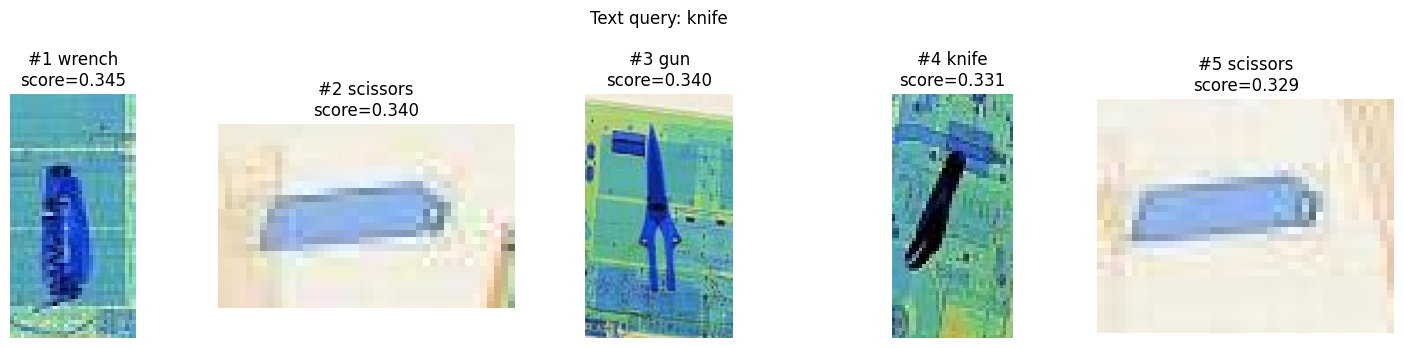

,rank,crop_id,split,class_name,score,is_correct,crop_path
6038,1,train_042372_jpg.rf.ed9dcc93d3583accc3a174959b...,train,wrench,0.344544,False,data\crops\train\train_042372_jpg.rf.ed9dcc93d...
6924,2,valid_028041_jpg.rf.3acd6679b11ec0921605886f0f...,valid,scissors,0.339774,False,data\crops\valid\valid_028041_jpg.rf.3acd6679b...
1830,3,train_024692_jpg.rf.20c56c7a84ee2a84a8c71633e6...,train,gun,0.339658,False,data\crops\train\train_024692_jpg.rf.20c56c7a8...
5655,4,train_040625_jpg.rf.fa36203f0bb22999a6b0c1bb3b...,train,knife,0.331034,True,data\crops\train\train_040625_jpg.rf.fa36203f0...
3176,5,train_030972_jpg.rf.7b99dad3c0df803bfd707a01fa...,train,scissors,0.329118,False,data\crops\train\train_030972_jpg.rf.7b99dad3c...


In [24]:
def resolve_crop_path(crop_path):
    crop_path = Path(crop_path)
    return crop_path if crop_path.is_absolute() else PROJECT_ROOT / crop_path


def show_top5_text_query_class(query_class_name):
    query_class_index = CLASS_NAMES.index(query_class_name)
    scores = similarity_text_to_image[query_class_index]
    top_indices_for_query = top_indices(scores, 5)
    top_rows = metadata.iloc[top_indices_for_query].copy()
    top_rows.insert(0, "rank", range(1, len(top_rows) + 1))
    top_rows["score"] = scores[top_indices_for_query]
    top_rows["is_correct"] = top_rows["class_name"].eq(query_class_name)

    fig, axes = plt.subplots(1, len(top_rows), figsize=(15, 3.5))
    if len(top_rows) == 1:
        axes = [axes]
    for ax, (_, row) in zip(axes, top_rows.iterrows()):
        image = Image.open(resolve_crop_path(row["crop_path"])).convert("RGB")
        ax.imshow(image)
        ax.set_title(f"#{row['rank']} {row['class_name']}\nscore={row['score']:.3f}")
        ax.axis("off")
    fig.suptitle(f"Text query: {query_class_name}")
    plt.tight_layout()
    plt.show()
    return top_rows[["rank", "crop_id", "split", "class_name", "score", "is_correct", "crop_path"]]


top5_knife_results = show_top5_text_query_class("knife")
top5_knife_results


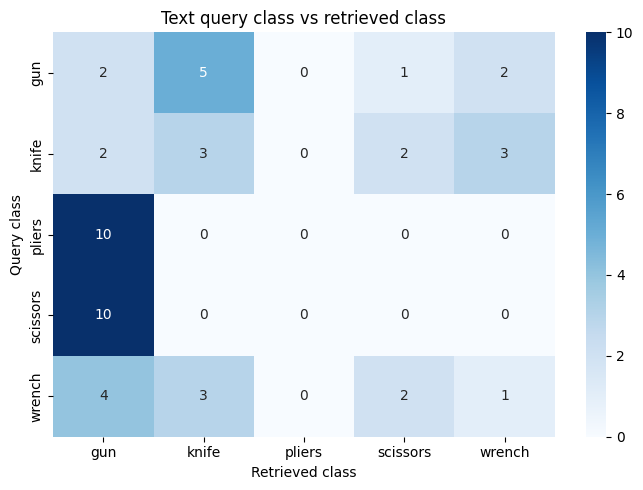

In [25]:
retrieval_results = pd.DataFrame(retrieval_rows)
top10_text = retrieval_results[retrieval_results["evaluation_type"] == "text_to_image"]
confusion = pd.crosstab(top10_text["query_class_name"], top10_text["retrieved_class_name"]).reindex(index=CLASS_NAMES, columns=CLASS_NAMES, fill_value=0)

plt.figure(figsize=(7, 5))
sns.heatmap(confusion, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Retrieved class")
plt.ylabel("Query class")
plt.title("Text query class vs retrieved class")
plt.tight_layout()
plt.show()

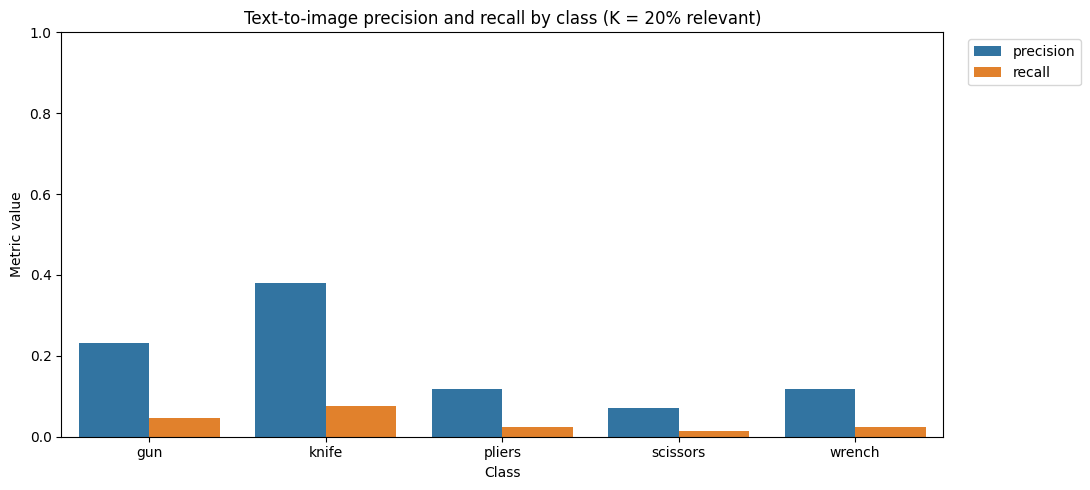

In [26]:
text_metrics_20pct = text_percent_metrics[text_percent_metrics["evaluation_scope"] == "20pct_relevant"].copy()

text_metrics_melted = text_metrics_20pct.melt(
    id_vars=["query_class_name", "evaluation_scope", "k"],
    value_vars=["precision", "recall"],
    var_name="metric",
    value_name="value",
)
plt.figure(figsize=(11, 5))
sns.barplot(data=text_metrics_melted, x="query_class_name", y="value", hue="metric")
plt.ylim(0, 1)
plt.xlabel("Class")
plt.ylabel("Metric value")
plt.title("Text-to-image precision and recall by class (K = 20% relevant)")
plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()


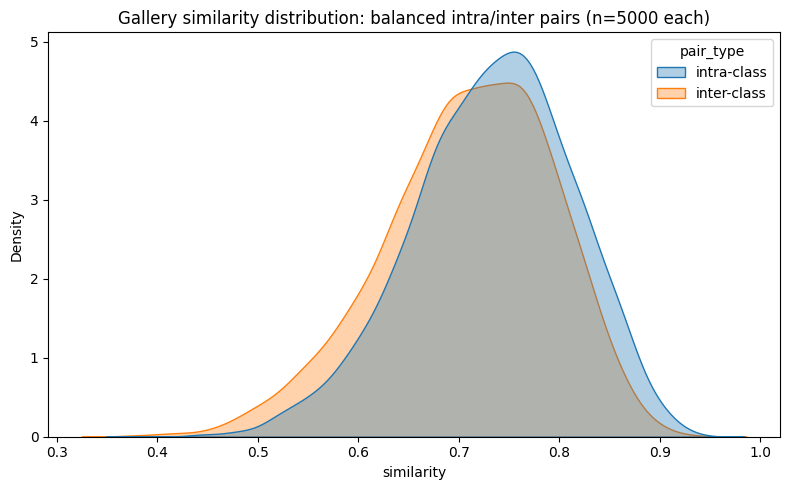

,count,mean,std,min,25%,50%,75%,max
pair_type,,,,,,,,
inter-class,5000.0,0.708995,0.085268,0.371076,0.654606,0.716136,0.771613,0.940107
intra-class,5000.0,0.732768,0.080322,0.392635,0.680497,0.737157,0.790119,0.940502


In [27]:
rng = np.random.default_rng(42)
TARGET_PAIRS_PER_GROUP = 5000

class_to_indices = {
    class_name: metadata.index[metadata["class_name"] == class_name].to_numpy()
    for class_name in CLASS_NAMES
}
valid_classes = [class_name for class_name, indices in class_to_indices.items() if len(indices) >= 2]

intra_pairs = []
inter_pairs = []
max_attempts = TARGET_PAIRS_PER_GROUP * 20
attempts = 0

while len(intra_pairs) < TARGET_PAIRS_PER_GROUP and attempts < max_attempts:
    attempts += 1
    class_name = rng.choice(valid_classes)
    i, j = rng.choice(class_to_indices[class_name], size=2, replace=False)
    intra_pairs.append((int(i), int(j)))

attempts = 0
while len(inter_pairs) < TARGET_PAIRS_PER_GROUP and attempts < max_attempts:
    attempts += 1
    class_a, class_b = rng.choice(CLASS_NAMES, size=2, replace=False)
    if len(class_to_indices[class_a]) == 0 or len(class_to_indices[class_b]) == 0:
        continue
    i = int(rng.choice(class_to_indices[class_a]))
    j = int(rng.choice(class_to_indices[class_b]))
    inter_pairs.append((i, j))

balanced_pair_count = min(len(intra_pairs), len(inter_pairs))
intra_pairs = intra_pairs[:balanced_pair_count]
inter_pairs = inter_pairs[:balanced_pair_count]

def pair_similarities(pairs):
    if not pairs:
        return np.array([], dtype="float32")
    i = np.array([pair[0] for pair in pairs])
    j = np.array([pair[1] for pair in pairs])
    return np.sum(embeddings[i] * embeddings[j], axis=1)

pairs_df = pd.DataFrame({
    "similarity": np.concatenate([pair_similarities(intra_pairs), pair_similarities(inter_pairs)]),
    "pair_type": (["intra-class"] * balanced_pair_count) + (["inter-class"] * balanced_pair_count),
})

assert pairs_df["pair_type"].value_counts().nunique() == 1, "Intra/inter samples must be balanced"

plt.figure(figsize=(8, 5))
sns.kdeplot(data=pairs_df, x="similarity", hue="pair_type", common_norm=False, fill=True, alpha=0.35)
plt.title(f"Gallery similarity distribution: balanced intra/inter pairs (n={balanced_pair_count} each)")
plt.tight_layout()
plt.show()

pairs_df.groupby("pair_type")["similarity"].describe()


In [28]:
errors = retrieval_results[(retrieval_results["rank"] <= 5) & (~retrieval_results["is_correct"])]
errors.head(20)

,evaluation_type,query_id,query_class_name,retrieved_crop_id,retrieved_class_name,rank,score,is_correct,query_split,retrieved_split
0,text_to_image,gun,gun,train_042372_jpg.rf.ed9dcc93d3583accc3a174959b...,wrench,1,0.321751,False,NaN,NaN
2,text_to_image,gun,gun,train_040517_jpg.rf.59b312f980fec4ec101165a33d...,knife,3,0.312220,False,NaN,NaN
3,text_to_image,gun,gun,train_041862_jpg.rf.bcf1d78e307e68de2b4ba10a68...,knife,4,0.309794,False,NaN,NaN
4,text_to_image,gun,gun,valid_037531_jpg.rf.2b0f237fe8cc0560d4bfbcb690...,knife,5,0.309350,False,NaN,NaN
10,text_to_image,knife,knife,train_042372_jpg.rf.ed9dcc93d3583accc3a174959b...,wrench,1,0.344544,False,NaN,NaN
11,text_to_image,knife,knife,valid_028041_jpg.rf.3acd6679b11ec0921605886f0f...,scissors,2,0.339774,False,NaN,NaN
12,text_to_image,knife,knife,train_024692_jpg.rf.20c56c7a84ee2a84a8c71633e6...,gun,3,0.339658,False,NaN,NaN
14,text_to_image,knife,knife,train_030972_jpg.rf.7b99dad3c0df803bfd707a01fa...,scissors,5,0.329118,False,NaN,NaN
20,text_to_image,pliers,pliers,train_024692_jpg.rf.20c56c7a84ee2a84a8c71633e6...,gun,1,0.368464,False,NaN,NaN
21,text_to_image,pliers,pliers,train_023016_jpg.rf.e417610405471b31e5efbdd74f...,gun,2,0.349872,False,NaN,NaN
